# LSTM - based sentiment analysis

Importing necessary packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
from keras import backend as K
from keras.layers import Input, Embedding, Multiply, Permute, Lambda
from keras.layers import LSTM, Dense, Bidirectional, Dropout, BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
from sklearn.model_selection import train_test_split

## 1. Preparing the data

### 1.1 Extracting the data

Loading the dataset from the .csv file

In [6]:
df = pd.read_csv('../data/all_emotions_mini.csv', sep='|')
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,text,emotion
0,i'm so bored i could read an entire book in on...,bored
1,the smell of a freshly baked cinnamon roll is ...,neutral
2,my heart races with anxiety every time i think...,anxious
3,the love between a parent and child is unbreak...,love
4,there's nothing quite like the feeling of bein...,love


Converting emotions to one-hot encoded numpy array

In [7]:
emotions = pd.get_dummies(df['emotion'])
emotions = np.array(emotions.values)
print(emotions, emotions.shape)

[[0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]] (7702, 14)


Converting texts into numpy array

In [8]:
texts = np.array(df['text'].values)
print(texts)

["i'm so bored i could read an entire book in one sitting"
 'the smell of a freshly baked cinnamon roll is comforting'
 'my heart races with anxiety every time i think about it.' ...
 "i'm hopeful that my career will take off"
 'the love i have for my pet brings me endless joy.'
 "i'm so bored out of my mind that i'm considering taking up knitting to pass the time."]


### 1.2 Text vectorization

Defining some constants that will be used for tikenizing the texts

In [9]:
MAX_WORDS = 3000
MAX_TEXT_LEN = 30
FILTERS='–"—#$%&amp;()*+,-./:;<=>?@[\\]^_`{|}~\t\n\r«»'

Creating a Tokenizer instance from Keras and fitting it on our corpus

In [12]:
tokenizer = Tokenizer(num_words=MAX_WORDS, filters=FILTERS, lower=True, split=' ', char_level=False)
tokenizer.fit_on_texts(texts)
tokenizer.fit_on_texts(pd.read_csv('../data/all_emotions_mini.csv', sep='|')['text'].values)

Vectorizing text data

In [13]:
vectorized_texts = tokenizer.texts_to_sequences(texts)
vectorized_texts = pad_sequences(vectorized_texts, maxlen=MAX_TEXT_LEN)
print(vectorized_texts)

[[  0   0   0 ...  17 123 482]
 [  0   0   0 ...  15  40 450]
 [  0   0   0 ... 318  23  32]
 ...
 [  0   0   0 ...   8  54 220]
 [  0   0   0 ...   6 502 127]
 [  0   0   0 ...   1  56   6]]


### 1.3 Preparing training and testing sets

Splitting the dataset into training (80%) and testing (20%) sets

In [16]:
x_train, x_test, y_train, y_test = train_test_split(vectorized_texts, emotions, test_size=0.2)

In [17]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(6161, 30) (1541, 30)
(6161, 14) (1541, 14)


## 2. Creating and training the model

### 2.1 Building and training the model

Defining the architecture of the model

In [67]:
model = Sequential()
model.add(Embedding(MAX_WORDS, 64, input_length = MAX_TEXT_LEN))

model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(Dropout(0.5))
model.add(BatchNormalization())

model.add(LSTM(16))
model.add(Dropout(0.5))
model.add(BatchNormalization())

model.add(Dense(14, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 30, 64)            192000    
                                                                 
 bidirectional_10 (Bidirecti  (None, 30, 64)           24832     
 onal)                                                           
                                                                 
 dropout_11 (Dropout)        (None, 30, 64)            0         
                                                                 
 batch_normalization_11 (Bat  (None, 30, 64)           256       
 chNormalization)                                                
                                                                 
 lstm_12 (LSTM)              (None, 16)                5184      
                                                                 
 dropout_12 (Dropout)        (None, 16)               

In [19]:
def attention(input_tensor):
    # input_tensor.shape = (batch_size, time_steps, input_dim)
    time_steps = input_tensor.shape[1]
    input_dim = input_tensor.shape[2]

    # Compute attention scores
    a = Permute((2, 1))(input_tensor)
    a = Dense(time_steps, activation='sigmoid')(a)
    a = Dense(time_steps, activation='softmax')(a)

    # Apply attention weights
    a = Permute((2, 1))(a)
    a = Multiply()([input_tensor, a])
    a = Lambda(lambda x: K.sum(x, axis=1))(a)
    return a

In [44]:
input_layer = Input(shape=(MAX_TEXT_LEN,))
embedding_layer = Embedding(MAX_WORDS, 64, input_length=MAX_TEXT_LEN)(input_layer)

lstm_layer1 = Bidirectional(LSTM(32, return_sequences=True))(embedding_layer)
dropout_layer1 = Dropout(0.5)(lstm_layer1)
batchnorm_layer1 = BatchNormalization()(dropout_layer1)

lstm_layer2 = Bidirectional(LSTM(16, return_sequences=True))(batchnorm_layer1)
dropout_layer2 = Dropout(0.5)(lstm_layer2)
batchnorm_layer2 = BatchNormalization()(dropout_layer2)

# Add attention mechanism
attention_layer = attention(lstm_layer2)

output_layer = Dense(14, activation='sigmoid')(attention_layer)

model = Model(inputs=input_layer, outputs=output_layer)

In [45]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 30)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 30, 32)       96000       ['input_3[0][0]']                
                                                                                                  
 bidirectional_4 (Bidirectional  (None, 30, 32)      6272        ['embedding_2[0][0]']            
 )                                                                                                
                                                                                                  
 dropout_4 (Dropout)            (None, 30, 32)       0           ['bidirectional_4[0][0]']  

Compiling the model

In [68]:
model.compile(loss=['categorical_crossentropy'], metrics=['accuracy'], optimizer=Adam(0.0001))

Training the model

In [80]:
history = model.fit(x_train, y_train, batch_size=32, epochs=5, validation_split=0.2)

Epoch 1/5
154/154 [==============================] - 8s 50ms/step - loss: 0.4656 - accuracy: 0.9048 - val_loss: 0.4581 - val_accuracy: 0.8873
Epoch 2/5
154/154 [==============================] - 7s 47ms/step - loss: 0.4574 - accuracy: 0.9052 - val_loss: 0.4617 - val_accuracy: 0.8889
Epoch 3/5
154/154 [==============================] - 7s 45ms/step - loss: 0.4433 - accuracy: 0.9058 - val_loss: 0.4591 - val_accuracy: 0.8881
Epoch 4/5
154/154 [==============================] - 7s 47ms/step - loss: 0.4370 - accuracy: 0.9085 - val_loss: 0.4559 - val_accuracy: 0.8905
Epoch 5/5
154/154 [==============================] - 7s 47ms/step - loss: 0.4173 - accuracy: 0.9081 - val_loss: 0.4609 - val_accuracy: 0.8913


### 2.2 Visualizing model training history

Summarizing history for loss

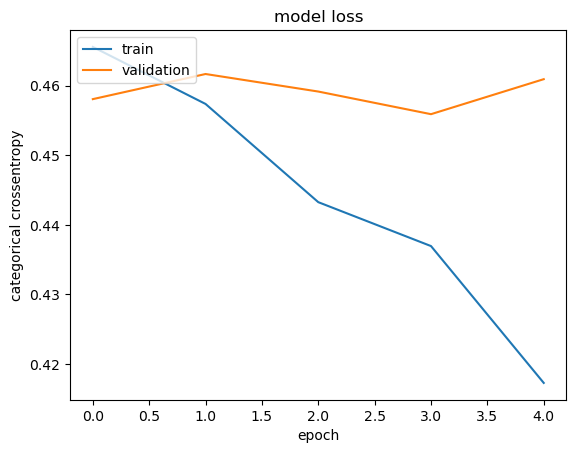

In [81]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('categorical crossentropy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Summarizing history for accuracy

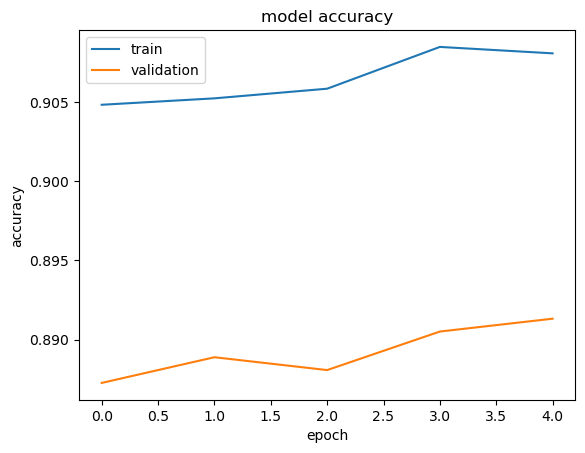

In [82]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### 2.3 Testing the model

##### Evaluating the model

In [83]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'loss: {loss}')
print(f'accuracy:{accuracy}')

49/49 [==============================] - 1s 15ms/step - loss: 0.4333 - accuracy: 0.8955
loss: 0.43332087993621826
accuracy:0.89552241563797


*The accuracy is about 90%*

##### Testing on examples

Helper function to detokenize the text

In [84]:
reverse_word_map = dict(map(reversed, tokenizer.word_index.items()))

def sequence_to_text(list_of_indices):
    words = [reverse_word_map.get(letter) for letter in list_of_indices]
    return(words)

Printing all the unique emotion entries in the dataframe

In [85]:
emotions_list = list(df['emotion'].unique())
emotions_list

['bored',
 'neutral',
 'anxious',
 'love',
 'regretful',
 'guilty',
 'sad',
 'fearful',
 'grateful',
 'excited',
 'angry',
 'proud',
 'hopeful',
 'happy']

In [86]:
examples = {
    'The sun is shining, the birds are singing, and life is full of endless possibilities!': 'happy',
    'The once-bustling streets are now silent and empty, as the world grapples with the devastating effects of a global pandemic.': 'sad',
    'I am infuriated by the blatant disregard for basic human rights and equality that continues to plague our society.': 'angry',
    'The sound of thunder in the distance filled her with fear, as she knew a storm was brewing and she was alone in the house.': 'fearful',
    'As she waited for the exam results to be posted online, her heart raced with anxiety and she couldn\'t stop second-guessing her answers.': 'anxious',
    'I can hardly contain my excitement about the upcoming trip to Europe - the thought of exploring new cities and immersing myself in different cultures fills me with anticipation!': 'excited',
    'Staring at the clock, watching the minutes tick by, he couldn\'t help but feel bored out of his mind in the never-ending meeting.': 'bored',
    'As she looked around the dinner table surrounded by her loved ones, she felt an overwhelming sense of gratitude for the warmth and comfort of their company.': 'grateful',
    'He couldn\'t shake the feeling of guilt as he realized he had forgotten his best friend\'s birthday, despite promising to make it special.': 'guilty',
    'The way that people from all over the world came together to support each other during the pandemic gives me hope that we can overcome any challenge when we stand united.': 'hopeful',
    'Whenever I\'m with you, my heart skips a beat and I can\'t help but feel an overwhelming sense of love and happiness.': 'love',
    'She felt an immense sense of pride as she watched her daughter receive her diploma, knowing that all her hard work and dedication had paid off in such a meaningful way.': 'proud',
    'He looked back on his life with regret, wishing he had taken more risks and pursued his passions instead of always playing it safe.': 'regretful',
    'The cat sat lazily on the windowsill, watching the world go by outside.': 'neutral'
}

In [87]:
correct = 0

for example, emotion in examples.items():
  tokens = tokenizer.texts_to_sequences([example])[0]
  restored_sentence = sequence_to_text(tokens)
  pad_tokens = pad_sequences([tokens], maxlen=MAX_TEXT_LEN)
  prediction = sorted(emotions_list)[np.argmax(model.predict(pad_tokens))]

  if prediction == emotion:
      correct += 1

  print('Input Sentence:')
  print(example)
  print('Restored Sentence:')
  print(restored_sentence)
  print(f'Expected output: {emotion}')
  print(f'Model output: {prediction}')

1/1 [==============================] - 0s 33ms/step
Input Sentence:
The sun is shining, the birds are singing, and life is full of endless possibilities!
Restored Sentence:
['the', 'sun', 'is', 'shining', 'the', 'birds', 're', 'singing', 'nd', 'life', 'is', 'full', 'of', 'endless']
Expected output: happy
Model output: happy
1/1 [==============================] - 0s 38ms/step
Input Sentence:
The once-bustling streets are now silent and empty, as the world grapples with the devastating effects of a global pandemic.
Restored Sentence:
['the', 'once', 'streets', 're', 'now', 'nd', 'e', 'ty', 's', 'the', 'world', 'gr', 'with', 'the', 'dev', 'st', 'ting', 'effects', 'of', 'glob', 'l', 'nde', 'ic']
Expected output: sad
Model output: sad
1/1 [==============================] - 0s 84ms/step
Input Sentence:
I am infuriated by the blatant disregard for basic human rights and equality that continues to plague our society.
Restored Sentence:
['i', 'infuri', 'ted', 'by', 'the', 'bl', 't', 'nt', 'disr

In [88]:
print(f'Predicted correctly {correct} / 14')

Predicted correctly 12 / 14


In [269]:
model.save('../models/model_attention')

In [44]:
import tensorflow as tf
new_model = tf.keras.models.load_model('../models/model_attention')

In [45]:
loss, accuracy = new_model.evaluate(x_test, y_test)
print(f'loss: {loss}')
print(f'accuracy:{accuracy}')

1133/1133 [==============================] - 121s 104ms/step - loss: 0.3747 - accuracy: 0.8993
loss: 0.3747382164001465
accuracy:0.8993319869041443
